# GLM-5.3-Flash 这条线做到哪了

任务清单在 `glm53_flash/results/REPRO_PLAN.md`：用 GLM-5.3-Flash 当提案模型，
复现 LDM v0.1 论文（[arXiv:2608.15669](https://arxiv.org/abs/2608.15669)）的主要结论。

~~划掉的是做完的~~；没做完的加粗，每一项配一个 notebook。


## 一句话

服务部署完了，C1 也真跑完了 —— **但没复现出论文的结论**。
论文说 LDM 比 LLM-only 好 2.4 倍，我们量出来 **0.97 倍**，
三个种子里只有一个 LDM 领先。C2 和 C3 从一开始就跑不了，卡在依赖和数据上。


## 图 1 — 三个场景现在各在什么位置

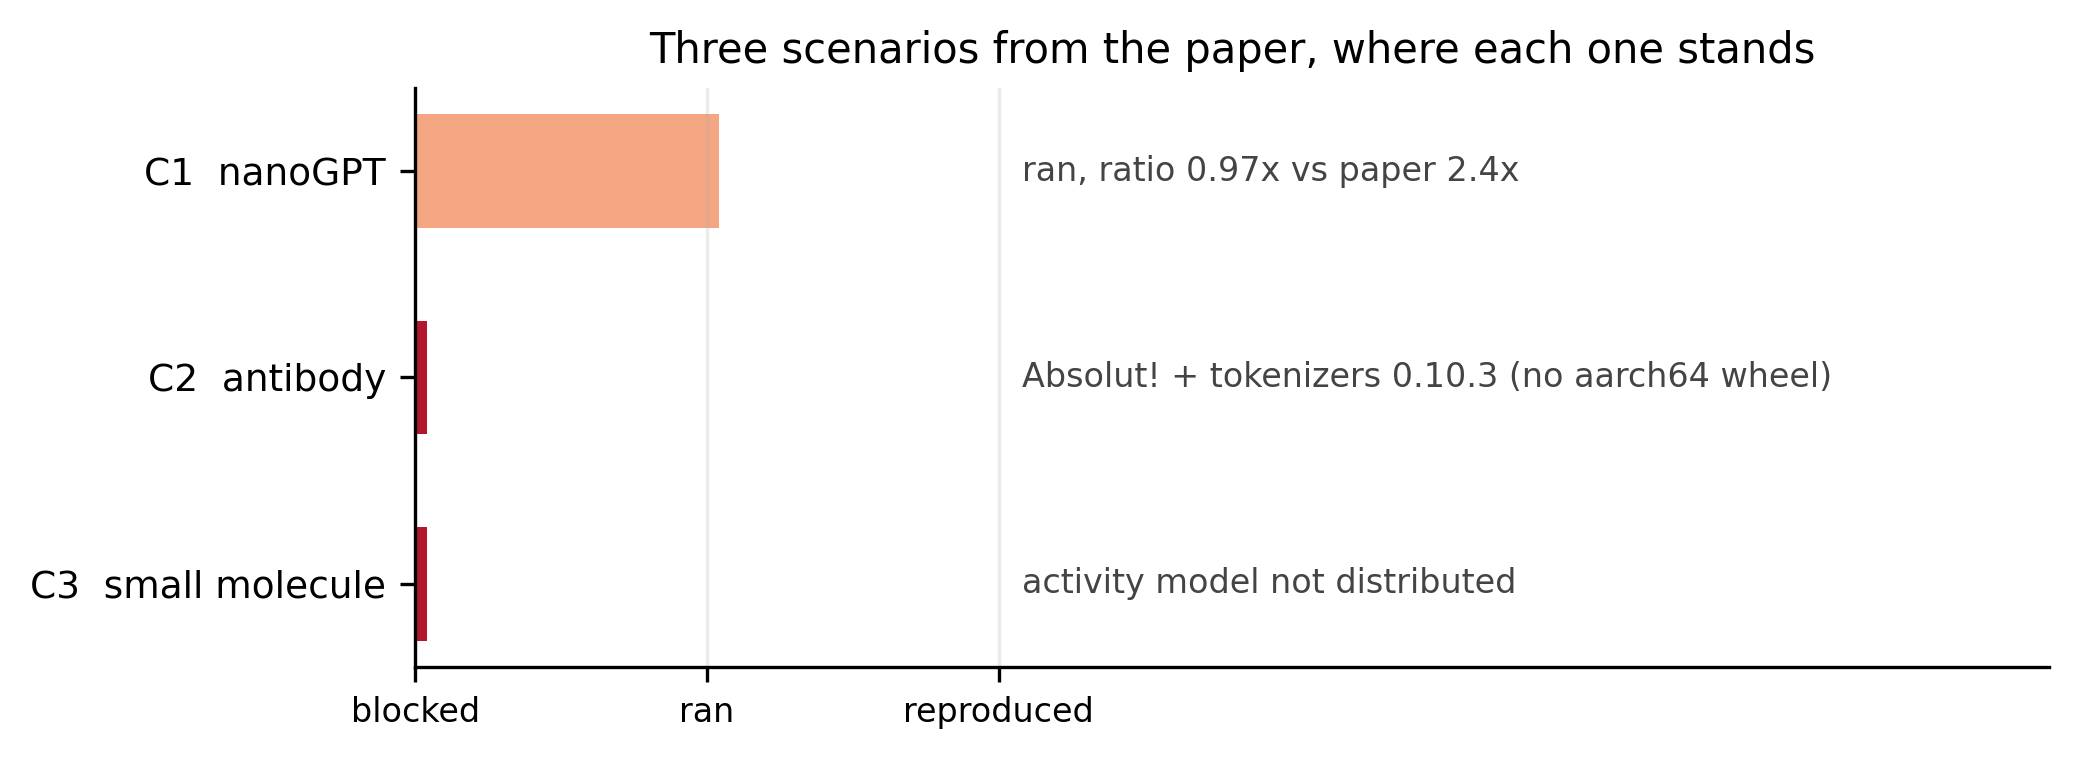

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})
R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/glm53_flash/results")

d = json.loads((R / "c1_repro.json").read_text())

# 0 = blocked, 1 = ran to completion, 2 = ran and matched the paper
scenes = [
    ("C1  nanoGPT",      1, f'ran, ratio {d["ratio_mean"]:.2f}x vs paper {d["paper_ratio"]}x'),
    ("C2  antibody",     0, "Absolut! + tokenizers 0.10.3 (no aarch64 wheel)"),
    ("C3  small molecule", 0, "activity model not distributed"),
]
fig, ax = plt.subplots(figsize=(7.0, 2.6))
col = {0: "#b2182b", 1: "#f4a582", 2: "#1a9850"}
for i, (name, st, note) in enumerate(scenes):
    ax.barh(i, st + .04, color=col[st], height=.55)
    ax.text(2.08, i, note, va="center", fontsize=8, color="#444444")
ax.set_yticks(range(len(scenes)))
ax.set_yticklabels([s[0] for s in scenes], fontsize=9)
ax.invert_yaxis()
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["blocked", "ran", "reproduced"], fontsize=8)
ax.set_xlim(0, 5.6); ax.grid(axis="y", alpha=0)
ax.set_title("Three scenarios from the paper, where each one stands", fontsize=10)
plt.tight_layout(); plt.show()

**怎么读**：没有一条走到最右边。C1 跑通了但比值对不上，C2 和 C3 连起跑线都没到。

## ~~部署~~ —— 做完了，就是本 PR

~~官方 arm64/cu129 镜像 + apptainer，TP4，端口 8383，OpenAI 兼容。
FP8 权重 306 GiB，每卡约 77 GiB，热缓存下一分钟内加载完。~~

~~pip 和源码构建都试过，都不行。pip 装得上但没有 `Glm5Next` 架构，
vLLM 不吭声地退回 transformers 后端，很久之后死在 KDA 的 `k_conv1d`。
源码构建六轮没成，第 5、6 轮 CUTLASS 报的错看着像 CUDA 版本问题，
其实是 `-ccbin` 没传、宿主编译器落到了 gcc-7。~~

~~容器里四个坑全写进了 `serve_vllm.sh`，`ci/check_glm53_deploy.py` 盯着它们
不被人顺手删掉。细节见 [README.md](README.md)。~~

## C1 nanoGPT：~~跑完了~~，但**结论对不上**

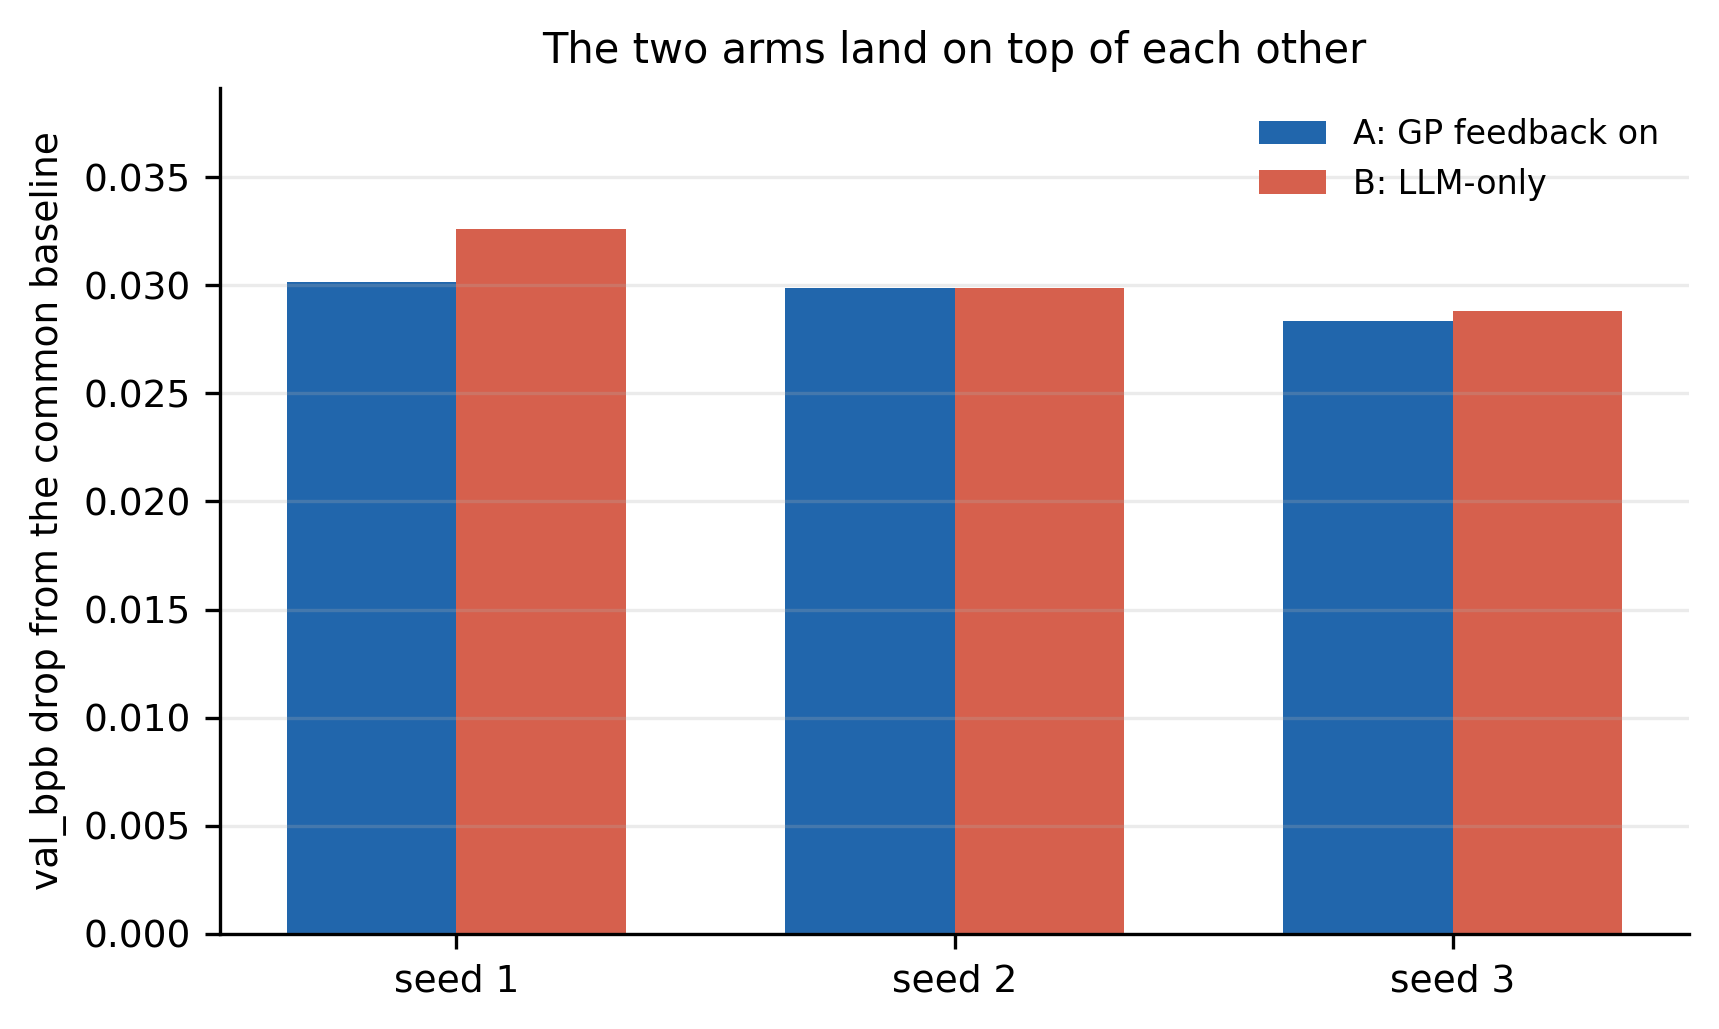

  seed 1: 0.92x  seed 2: 1.00x  seed 3: 0.98x
  mean 0.97x    paper 2.4x


In [2]:
runs = d["runs"]
fig, ax = plt.subplots(figsize=(5.8, 3.5))
seeds = sorted({r["seed"] for r in runs}); w = .34
for i, (arm, c, lab) in enumerate([("A", "#2166ac", "A: GP feedback on"),
                                   ("B", "#d6604d", "B: LLM-only")]):
    vals = [next(r["delta"] for r in runs if r["arm"]==arm and r["seed"]==s) for s in seeds]
    ax.bar([s + (i-.5)*w for s in seeds], vals, width=w, color=c, label=lab)
ax.set_xticks(seeds); ax.set_xticklabels([f"seed {s}" for s in seeds])
ax.set_ylabel("val_bpb drop from the common baseline")
ax.set_title("The two arms land on top of each other", fontsize=10)
ax.set_ylim(0, max(r["delta"] for r in runs)*1.2)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

print("  " + "  ".join(f'seed {k}: {v:.2f}x' for k, v in sorted(d["ratio_per_seed"].items())))
print(f'  mean {d["ratio_mean"]:.2f}x    paper {d["paper_ratio"]}x')

~~设计是成对的：A 组开 GP 引导（`acquisition-feedback=brief`），B 组关掉，
其余全部一样 —— 同一个提案模型、同一份起始代码、`breadth=1 depth=1`、
`warmup=5`、`iterations=40`、每次评测真训练 300 秒。
3 个种子 × 2 组 = 6 条轨迹，每条独占一张卡。~~

~~三轮起跑暴露的四个缺陷都修了：服务和实验分作业导致空跑、
`breadth×depth` 被误当成打分候选数（害 A 组多跑 7.7 倍评测）、
自设 `CUDA_VISIBLE_DEVICES` 指向不存在的卡、起服漏了 tool calling 标志。~~

**没做完的是解释这个差距** → [01_c1_ratio_gap.ipynb](status_notebooks/01_c1_ratio_gap.ipynb)

三个种子挤在 0.92–1.00 之间，看不出 GP 引导有什么用。差是真的，
但**差在哪还不知道**：可能是 GLM-5.3-Flash 跟论文用的模型不一样，
可能是 40 轮不够（论文跑 100 轮），也可能是 `acquisition-feedback`
根本不是论文说的那件事。三条都没验。

## C2 抗体：**跑不了**

→ [02_c2_antibody_blocked.ipynb](status_notebooks/02_c2_antibody_blocked.ipynb)

两道坎。Absolut! 那个结构模拟器要单独装，是外部二进制。
更麻烦的是 `ldm-tts-antibody` 钉死 transformers 4.13，它拉的 tokenizers 0.10.3
在 aarch64 上没有轮子，得现编 Rust。这条已经实测失败过（TEST_REPORT E3）。

## C3 小分子：**跑不了**

→ [03_c3_small_molecule_blocked.ipynb](status_notebooks/03_c3_small_molecule_blocked.ipynb)

活性模型 `best_g12d_model.joblib` 不公开发，得找论文作者要。
Vina 二进制这边已经有了（小分子 RL 那条线在用），但没有那个活性模型，
C3 的评测口径就和论文对不上。

自己训一个替代品也不行 —— 超体积对活性模型的标定极其敏感，
换个模型 Pareto 前沿的形状就变了，+62.4% 那个数没有可比性。

## 六条轨迹的数

In [3]:
pd.DataFrame([
    {"arm": r["arm"], "seed": r["seed"], "evaluations": r["n_evals"],
     "first eval": f'{r["first"]:.6f}', "best": f'{r["best"]:.6f}',
     "drop": f'{r["delta"]:.6f}', "status": r["status"]}
    for r in sorted(runs, key=lambda x: (x["arm"], x["seed"]))
]).style.hide(axis="index")

arm,seed,evaluations,first eval,best,drop,status
A,1,41,0.994296,0.989182,0.030126,完成
A,2,44,0.994137,0.989434,0.029874,完成
A,3,43,1.016950,0.990983,0.028325,完成
B,1,37,1.075514,0.986707,0.032601,完成
B,2,37,1.048066,0.989440,0.029868,完成
B,3,39,1.046357,0.990497,0.028811,完成


基线是未改动的 `real_train.py` 实测 val_bpb 1.019308，
表里的 drop 都是从它算起的绝对下降。

## 东西在哪

| | |
|---|---|
| 复现计划与设计 | `glm53_flash/results/REPRO_PLAN.md` |
| 执行流水账 | `glm53_flash/results/RUNLOG.md` |
| C1 六条轨迹的数 | `glm53_flash/results/c1_repro.json` |
| 分析脚本 | `glm53_flash/code/analyze_repro.py` |
| 服务脚本与四个坑 | 本目录 |
